# Stokes Vectors

**Scott Prahl**

*April 2020*

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import numpy as np
import matplotlib.pyplot as plt

if sys.platform == "emscripten":
    import micropip
    await micropip.install("pypolar")

from pypolar import jones
from pypolar import mueller
from pypolar import visualization as vis

np.set_printoptions(suppress=True)  # print 1e-16 as zero

## Introduction

The basics of Stokes vectors and their implementation in the `pypolar` modules.  The basic ways of creating Stokes vectors is show as well as simple visualization.

This notebook could use some more work.

## Basic Polarization 

In [2]:
light = mueller.stokes_horizontal()
print("Stokes vector for horizontally-polarized light")
print(light)

light = mueller.stokes_linear(0)
print("Stokes vector for 0° linearly polarized light")
print(light)

light = mueller.stokes_vertical()
print("Stokes vector for vertically-polarized light")
print(light)

light = mueller.stokes_linear(np.pi / 2)
print("Stokes vector for 90° linearly polarized light")
print(light)

light = mueller.stokes_linear(np.radians(45))
print("Stokes vector for 45° linearly polarized light")
print(light)

light = mueller.stokes_linear(np.radians(-45))
print("Stokes vector for -45° linearly polarized light")
print(light)

light = mueller.stokes_linear(np.radians(30))
print("Stokes vector for 30° linearly polarized light")
print(light)

light = mueller.stokes_linear(np.radians(-60))
print("Stokes vector for -60° linearly polarized light")
print(light)


light = mueller.stokes_right_circular()
print("Stokes vector for right circularly polarized light")
print(light)

light = mueller.stokes_left_circular()
print("Stokes vector for left circularly polarized light")
print(light)

Stokes vector for horizontally-polarized light
[1 1 0 0]
Stokes vector for 0° linearly polarized light
[1. 1. 0. 0.]
Stokes vector for vertically-polarized light
[ 1 -1  0  0]
Stokes vector for 90° linearly polarized light
[ 1.0000000e+00 -1.0000000e+00  1.2246468e-16  0.0000000e+00]
Stokes vector for 45° linearly polarized light
[1.000000e+00 6.123234e-17 1.000000e+00 0.000000e+00]
Stokes vector for -45° linearly polarized light
[ 1.000000e+00  6.123234e-17 -1.000000e+00  0.000000e+00]
Stokes vector for 30° linearly polarized light
[1.        0.5       0.8660254 0.       ]
Stokes vector for -60° linearly polarized light
[ 1.        -0.5       -0.8660254  0.       ]
Stokes vector for right circularly polarized light
[1 0 0 1]
Stokes vector for left circularly polarized light
[ 1  0  0 -1]


## Stokes vectors for elliptical polarization

Examples from Appendix A in Kliger.

In [3]:
azimuth = 0
ellipticity = 0.5
light = mueller.stokes_elliptical(1, azimuth, ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

azimuth = 0
ellipticity = -0.5
light = mueller.stokes_elliptical(1, azimuth, ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

azimuth = 90
ellipticity = 0.5
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

azimuth = 90
ellipticity = -0.5
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

azimuth = 45
ellipticity = 0.414
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

azimuth = 45
ellipticity = -0.414
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

azimuth = 25.38
ellipticity = 0.342
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

azimuth = -64.62
ellipticity = -0.342
light = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
print("Elliptically polarized (azimuth=%.2f°, ellipticity=%.3f)" % (azimuth, ellipticity))
print(light)

Elliptically polarized (azimuth=0.00°, ellipticity=0.500)
[1.  0.6 0.  0.8]
Elliptically polarized (azimuth=0.00°, ellipticity=-0.500)
[ 1.   0.6  0.  -0.8]
Elliptically polarized (azimuth=90.00°, ellipticity=0.500)
[ 1.00000000e+00 -6.00000000e-01  7.34788079e-17  8.00000000e-01]
Elliptically polarized (azimuth=90.00°, ellipticity=-0.500)
[ 1.00000000e+00 -6.00000000e-01  7.34788079e-17 -8.00000000e-01]
Elliptically polarized (azimuth=45.00°, ellipticity=0.414)
[1.00000000e+00 4.33135864e-17 7.07364546e-01 7.06848922e-01]
Elliptically polarized (azimuth=45.00°, ellipticity=-0.414)
[ 1.00000000e+00  4.33135864e-17  7.07364546e-01 -7.06848922e-01]
Elliptically polarized (azimuth=25.38°, ellipticity=0.342)
[1.         0.50008973 0.61229734 0.61237426]
Elliptically polarized (azimuth=-64.62°, ellipticity=-0.342)
[ 1.         -0.50008973 -0.61229734 -0.61237426]


## Stokes to Jones Conversion


In [4]:
S = mueller.stokes_horizontal()
print("Stokes vector for horizontally-polarized light")
print(S)
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(J)
print("Actual Jones vector")
print(jones.field_horizontal())

Stokes vector for horizontally-polarized light
[1 1 0 0]
Jones conversion
[1.+0.j 0.+0.j]
Actual Jones vector
[1 0]


In [5]:
S = mueller.stokes_vertical()
print("Stokes vector for vertically-polarized light")
print(S)
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(J)
print("Actual Jones vector")
print(jones.field_vertical())

Stokes vector for vertically-polarized light
[ 1 -1  0  0]
Jones conversion
[0. 1.]
Actual Jones vector
[0 1]


In [6]:
angle = 30 * np.pi / 180
S = mueller.stokes_linear(angle)
print("Stokes vector for linearly-polarized light at %.1f°" % (angle * 180 / np.pi))
print(S)
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(J)
print("Actual Jones vector")
print(jones.field_linear(angle))

Stokes vector for linearly-polarized light at 30.0°
[1.        0.5       0.8660254 0.       ]
Jones conversion
[0.8660254+0.j 0.5      +0.j]
Actual Jones vector
[0.8660254 0.5      ]


In [7]:
S = mueller.stokes_right_circular()
print("Stokes vector for right-circular-polarized light")
print(S)
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(J)
print("Actual Jones vector")
print(jones.field_right_circular())

Stokes vector for right-circular-polarized light
[1 0 0 1]
Jones conversion
[0.70710678+0.j         0.        +0.70710678j]
Actual Jones vector
[0.70710678+0.j         0.        +0.70710678j]


In [8]:
S = mueller.stokes_left_circular()
print("Stokes vector for left-circular-polarized light")
print(S)
J = mueller.stokes_to_jones(S)
print("Jones conversion")
print(J)
print("Actual Jones vector")
print(jones.field_left_circular())

Stokes vector for left-circular-polarized light
[ 1  0  0 -1]
Jones conversion
[0.70710678+0.j         0.        -0.70710678j]
Actual Jones vector
[0.70710678+0.j         0.        -0.70710678j]


## Visualization

These only show the polarized component of the Stokes vector.

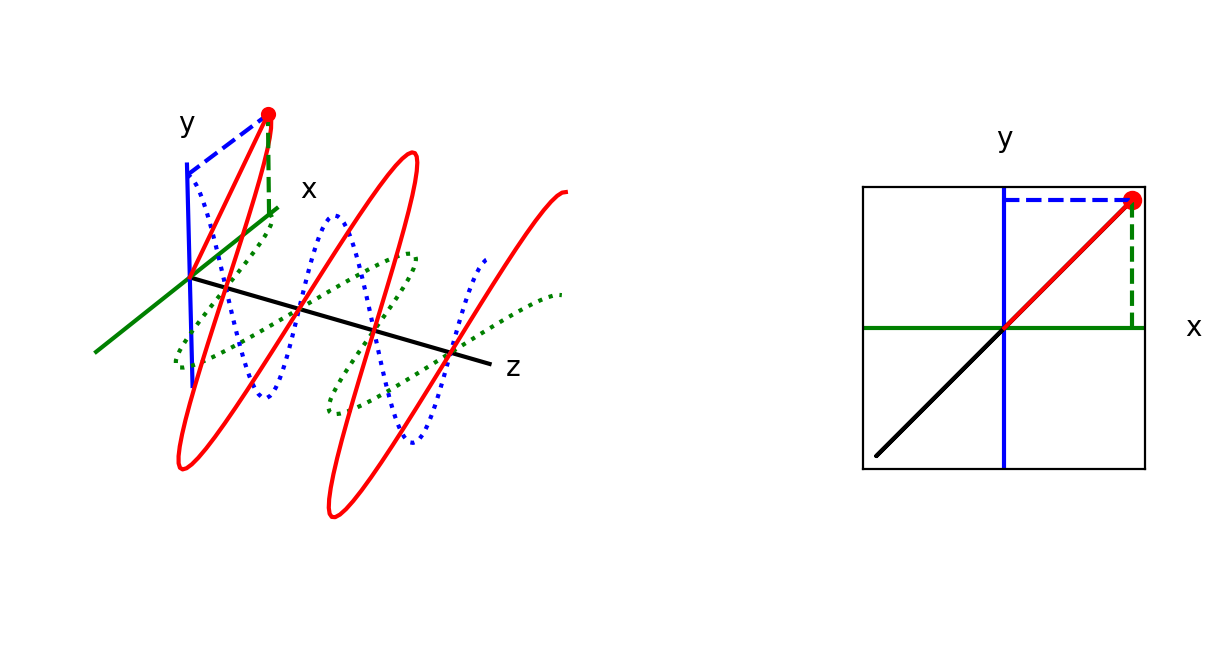

In [9]:
theta = np.radians(45)
v = mueller.stokes_linear(theta)
vis.draw_stokes_field(v)

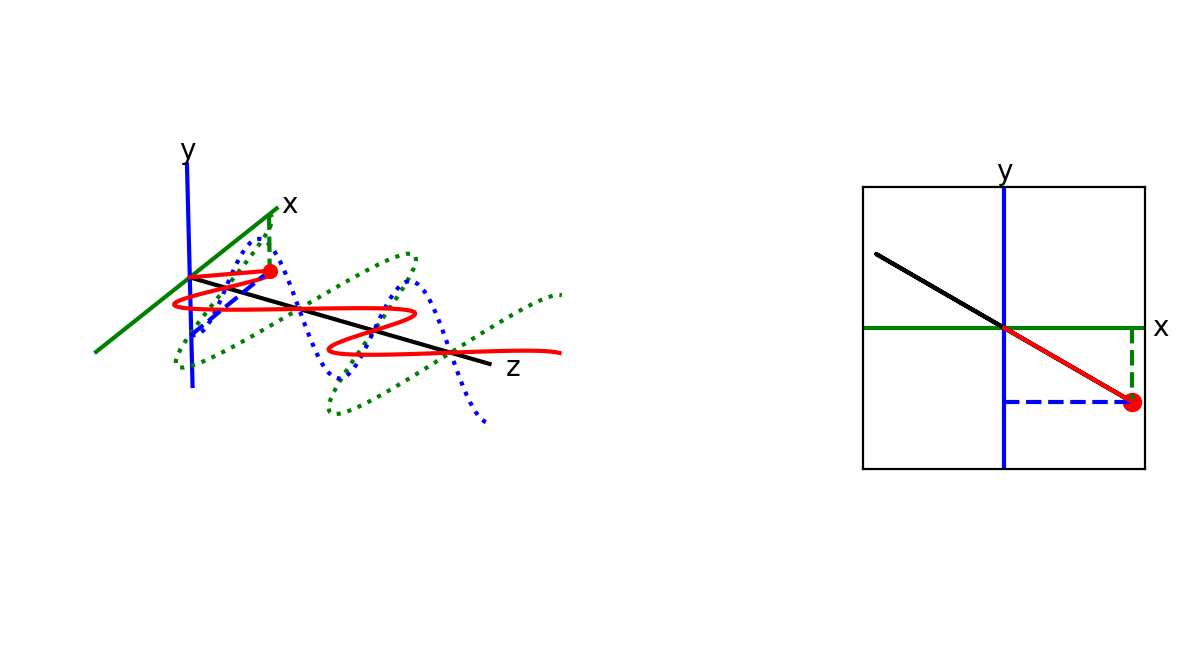

In [10]:
theta = np.radians(-30)
v = mueller.stokes_linear(theta)
vis.draw_stokes_field(v)

In [11]:
v = mueller.stokes_left_circular()
vis.draw_stokes_animated(v)

In [12]:
v = mueller.stokes_right_circular()
vis.draw_stokes_animated(v)

In [13]:
azimuth = -64.62
ellipticity = -0.342
v = mueller.stokes_elliptical(1, np.radians(azimuth), ellipticity)
vis.draw_stokes_animated(v)

## Field Interpretation

In [14]:
v = mueller.stokes_horizontal()
mueller.interpret(v)

I = 1.000
Q = 1.000
U = 0.000
V = 0.000


'not implemented yet'

In [15]:
v = mueller.stokes_vertical()
mueller.interpret(v)

I = 1.000
Q = -1.000
U = 0.000
V = 0.000


'not implemented yet'

In [16]:
theta = np.radians(45)
v = mueller.stokes_linear(theta)
mueller.interpret(v)

I = 1.000
Q = 0.000
U = 1.000
V = 0.000


'not implemented yet'

In [17]:
v = np.array([3 * np.exp(-1j * np.pi), 3 * np.exp(-1j * np.pi / 3)])
mueller.interpret(v)

Stokes vector must have four real elements


0